Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

Base: P10=146.38, P50=195.90, P90=243.68


Output()

Otimista: P10=149.49, P50=199.48, P90=247.24


Pessimista: P10=70.45, P50=119.09, P90=167.79


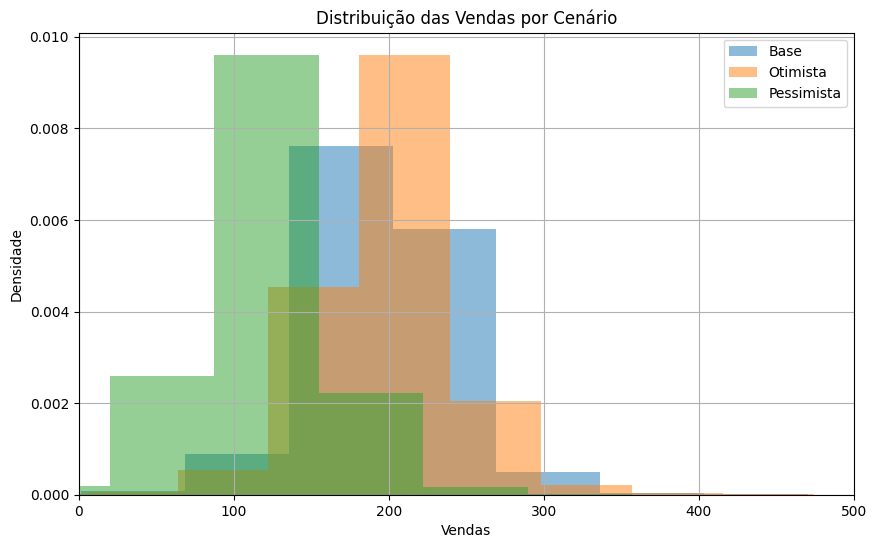

In [2]:
!pip install -q pymc arviz xarray pytensor
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import xarray as xr # Import xarray for explicit dataset construction

np.random.seed(42)

n=800
X=np.random.randn(n,4)
cols=["preco","gasto_ads","temperatura","eh_feriado"]
y=200-30*X[:,0]+15*X[:,1]+8*X[:,2]+40*X[:,3]+np.random.normal(0,15,n)
df=pd.DataFrame(X,columns=cols)
df["vendas"]=y

Xm,Xs=X.mean(0),X.std(0)
Xn=(X-Xm)/Xs

with pm.Model() as model:
    # Explicitly define dimensions for X_data to prevent MissingDimensionsError
    Xd=pm.Data("X_data",Xn, dims=['data_index', 'features'])
    w1=pm.Normal("w1",0,1,shape=(4,16), dims=["features", "hidden_units_l1"])
    b1=pm.Normal("b1",0,1,shape=(16,), dims=["hidden_units_l1"])
    w2=pm.Normal("w2",0,1,shape=(16,1), dims=["hidden_units_l1", "output_units"])
    b2=pm.Normal("b2",0,1)

    h=pt.tanh(pt.dot(Xd,w1)+b1)
    mu=pt.flatten(pt.dot(h,w2)+b2)

    sigma=pm.HalfNormal("sigma",20)
    pm.StudentT("obs",nu=5,mu=mu,sigma=sigma,observed=y)

    trace=pm.sample(1000,tune=1000,target_accept=0.9,chains=4)

def gerar_cenario(nome,x):
    xn=(x-Xm)/Xs
    with model:
        pm.set_data({"X_data":xn})
        ppc=pm.sample_posterior_predictive(trace,var_names=["obs"])
    am=ppc.posterior_predictive["obs"].values.flatten()
    p10,p50,p90=np.percentile(am,[10,50,90])
    print(f"{nome}: P10={p10:.2f}, P50={p50:.2f}, P90={p90:.2f}")
    return nome, am

# Define scenarios
# Base scenario is the mean of the features
cenario_base_X = Xm.reshape(1, -1)

# Optimistic scenario (lower price, higher ad spend, slightly higher temp, higher holiday factor)
cenario_otimista_X_values = np.array([
    Xm[0] - Xs[0],  # Lower 'preco'
    Xm[1] + Xs[1],  # Higher 'gasto_ads'
    Xm[2] + 0.5 * Xs[2], # Slightly higher 'temperatura'
    Xm[3] + Xs[3]   # Higher 'eh_feriado'
]).reshape(1, -1)

# Pessimistic scenario (higher price, lower ad spend, slightly lower temp, lower holiday factor)
cenario_pessimista_X_values = np.array([
    Xm[0] + Xs[0],  # Higher 'preco'
    Xm[1] - Xs[1],  # Lower 'gasto_ads'
    Xm[2] - 0.5 * Xs[2], # Slightly lower 'temperatura'
    Xm[3] - Xs[3]   # Lower 'eh_feriado'
]).reshape(1, -1)

# Generate predictions for each scenario
_, base_samples = gerar_cenario("Base", cenario_base_X)
_, otimista_samples = gerar_cenario("Otimista", cenario_otimista_X_values)
_, pessimista_samples = gerar_cenario("Pessimista", cenario_pessimista_X_values)

# Plotting
plt.figure(figsize=(10, 6))
plt.hist(base_samples, bins=40, alpha=0.5, label="Base", density=True)
plt.hist(otimista_samples, bins=40, alpha=0.5, label="Otimista", density=True)
plt.hist(pessimista_samples, bins=40, alpha=0.5, label="Pessimista", density=True)

plt.xlabel("Vendas")
plt.ylabel("Densidade")
plt.title("Distribuição das Vendas por Cenário")
plt.xlim(0, 500)
plt.legend()
plt.grid(True)
plt.show()

# Create a new InferenceData object with only the posterior and posterior_predictive groups,
# ensuring all data are standard NumPy arrays to avoid serialization issues.
new_idata_groups = {}

if hasattr(trace, 'posterior'):
    cleaned_posterior_data_vars = {}
    for var_name in trace.posterior.data_vars:
        # Convert values to NumPy arrays explicitly while preserving dims
        cleaned_posterior_data_vars[var_name] = (
            trace.posterior[var_name].dims,
            np.asarray(trace.posterior[var_name].values)
        )
    # Create a new xarray Dataset from the cleaned data_vars and original coords/attrs
    posterior_ds_clean = xr.Dataset(
        cleaned_posterior_data_vars,
        coords=trace.posterior.coords,
        attrs=trace.posterior.attrs
    )
    new_idata_groups["posterior"] = posterior_ds_clean

if hasattr(trace, 'posterior_predictive'):
    cleaned_posterior_predictive_data_vars = {}
    for var_name in trace.posterior_predictive.data_vars:
        # Convert values to NumPy arrays explicitly while preserving dims
        cleaned_posterior_predictive_data_vars[var_name] = (
            trace.posterior_predictive[var_name].dims,
            np.asarray(trace.posterior_predictive[var_name].values)
        )
    # Create a new xarray Dataset from the cleaned data_vars and original coords/attrs
    posterior_predictive_ds_clean = xr.Dataset(
        cleaned_posterior_predictive_data_vars,
        coords=trace.posterior_predictive.coords,
        attrs=trace.posterior_predictive.attrs
    )
    new_idata_groups["posterior_predictive"] = posterior_predictive_ds_clean

# Create the new InferenceData object from the cleaned datasets
if new_idata_groups:
    trace_to_save = az.InferenceData(**new_idata_groups)
    az.to_netcdf(trace_to_save, "trace_bnn_flow.nc")
else:
    print("Warning: No posterior or posterior_predictive found to save. File will not be created.")